# Final Project
## Getting data, basic EDA, tokenizing 

"https://www.kaggle.com/datasets/ahemateja19bec1025/musicgenerationdataset"


## Get and parse the files

In [1]:
%%bash

#!/usr/bin/env bash

# don't curl if already downloaded
[ -d musicgenerationdataset ] || {
  curl -L -o data.zip "https://www.kaggle.com/api/v1/datasets/download/ahemateja19bec1025/musicgenerationdataset"
  unzip data.zip -d musicgenerationdataset
}

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  393k  100  393k    0     0   807k      0 --:--:-- --:--:-- --:--:--  807k


Archive:  data.zip
  inflating: musicgenerationdataset/appass_1.mid  
  inflating: musicgenerationdataset/appass_2.mid  
  inflating: musicgenerationdataset/appass_3.mid  
  inflating: musicgenerationdataset/bach_846.mid  
  inflating: musicgenerationdataset/bach_847.mid  
  inflating: musicgenerationdataset/bach_850.mid  
  inflating: musicgenerationdataset/beethoven_hammerklavier_1.mid  
  inflating: musicgenerationdataset/beethoven_hammerklavier_2.mid  
  inflating: musicgenerationdataset/beethoven_hammerklavier_3.mid  
  inflating: musicgenerationdataset/beethoven_hammerklavier_4.mid  
  inflating: musicgenerationdataset/beethoven_les_adieux_1.mid  
  inflating: musicgenerationdataset/beethoven_les_adieux_2.mid  
  inflating: musicgenerationdataset/beethoven_les_adieux_3.mid  
  inflating: musicgenerationdataset/beethoven_opus10_1.mid  
  inflating: musicgenerationdataset/beethoven_opus10_2.mid  
  inflating: musicgenerationdataset/beethoven_opus10_3.mid  
  inflating: musicgenerat

In [2]:
from pathlib import Path

data_dir = Path("musicgenerationdataset")

midi_files = (
    list(data_dir.rglob("*.mid"))
    + list(data_dir.rglob("*.midi"))
)

print(f"Found {len(midi_files)} MIDI files")

for path in midi_files[:10]:
    print(path)

Found 32 MIDI files
musicgenerationdataset/beethoven_hammerklavier_4.mid
musicgenerationdataset/beethoven_opus10_2.mid
musicgenerationdataset/beethoven_les_adieux_1.mid
musicgenerationdataset/mond_2.mid
musicgenerationdataset/beethoven_opus22_4.mid
musicgenerationdataset/beethoven_opus22_1.mid
musicgenerationdataset/bach_850.mid
musicgenerationdataset/beethoven_opus90_2.mid
musicgenerationdataset/waldstein_2.mid
musicgenerationdataset/beethoven_opus10_3.mid


In [5]:
import pretty_midi

sample_path = midi_files[0]
midi = pretty_midi.PrettyMIDI(str(sample_path))

print("File:", sample_path.name)
print("Duration:", midi.get_end_time(), "seconds")
print("Estimated tempo:", midi.estimate_tempo())
print("Number of instruments:", len(midi.instruments))

for instrument in midi.instruments:
    print(
        instrument.name,
        "program:", instrument.program,
        "notes:", len(instrument.notes)
    )

File: beethoven_hammerklavier_4.mid
Duration: 641.8536508458311 seconds
Estimated tempo: 239.62741307322597
Number of instruments: 2
Piano right program: 0 notes: 4244
Piano left program: 0 notes: 3764


In [6]:
import pandas as pd

rows = []

for path in midi_files:
    midi = pretty_midi.PrettyMIDI(str(path)) # super nice for working with midi data

    for instrument_number, instrument in enumerate(midi.instruments):
        for note in instrument.notes:
            rows.append({
                "file": path.name,
                "instrument": instrument_number,
                "pitch": note.pitch,
                "velocity": note.velocity,
                "start": note.start,
                "end": note.end,
                "duration": note.end - note.start,
            })

notes_df = pd.DataFrame(rows)

print(notes_df.shape)
notes_df.head()

(122838, 7)


,file,instrument,pitch,velocity,start,end,duration
0,beethoven_hammerklavier_4.mid,0,65,46,0.546647,0.683309,0.136662
1,beethoven_hammerklavier_4.mid,0,65,50,0.728863,0.911078,0.182216
2,beethoven_hammerklavier_4.mid,0,77,46,0.911078,1.047740,0.136662
3,beethoven_hammerklavier_4.mid,0,77,59,1.093294,1.280630,0.187336
4,beethoven_hammerklavier_4.mid,0,77,51,1.694264,5.012004,3.317740


In [21]:
print("Number of songs:", notes_df["file"].nunique())
print("Total notes:", len(notes_df))
print("Average pitch:", notes_df["pitch"].mean())
print("Average duration:", notes_df["duration"].mean())
print("Average velocity:", notes_df["velocity"].mean())

Number of songs: 32
Total notes: 122838
Average pitch: 63.12374835148732
Average duration: 0.2806706192106337
Average velocity: 52.58719614451554


## Simple Data Analysis

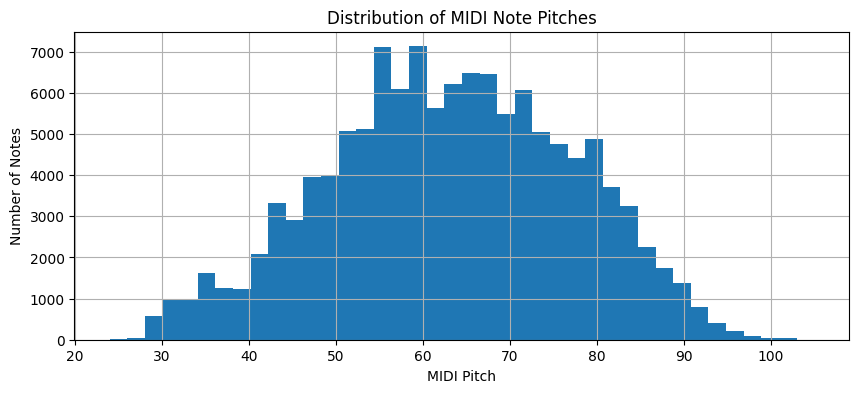

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
notes_df["pitch"].hist(bins=40)

plt.title("Distribution of MIDI Note Pitches")
plt.xlabel("MIDI Pitch")
plt.ylabel("Number of Notes")
plt.show()

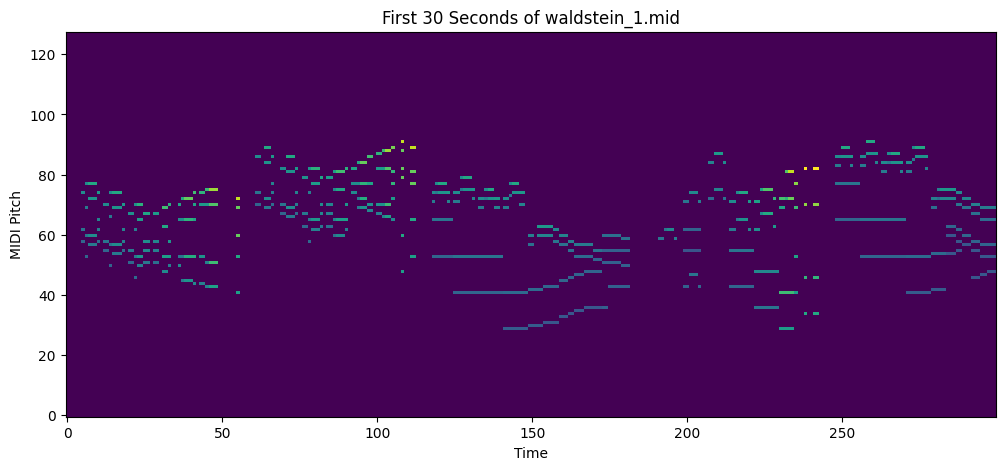

In [23]:
piano_roll = midi.get_piano_roll(fs=10)

plt.figure(figsize=(12, 5))
plt.imshow(
    piano_roll[:, :300],
    origin="lower",
    aspect="auto"
)

plt.title(f"First 30 Seconds of {sample_path.name}")
plt.xlabel("Time")
plt.ylabel("MIDI Pitch")
plt.show()

## Tokenize the notes

In [ ]:
def midi_to_tokens(path):
    midi = pretty_midi.PrettyMIDI(str(path))
    events = []

    for instrument in midi.instruments:
        if instrument.is_drum:
            continue

        for note in instrument.notes:
            events.append({
                "start": note.start,
                "pitch": note.pitch,
                "duration": note.end - note.start,
                "velocity": note.velocity,
            })

    events.sort(key=lambda event: event["start"])

    tokens = []
    previous_start = 0.0

    # each un
    for event in events:
        time_shift = round((event["start"] - previous_start) * 4) # creates unis of .25 seconds (design choice)
        duration = max(1, round(event["duration"] * 4))
        velocity = min(7, event["velocity"] // 16) # there are 128 MIDI values, and dividing by 16 gives 8 buckets

        tokens.extend([
            f"TIME_{time_shift}",
            f"PITCH_{event['pitch']}",
            f"DURATION_{duration}",
            f"VELOCITY_{velocity}",
        ])

        previous_start = event["start"]

    return tokens

In [25]:
sample_tokens = midi_to_tokens(midi_files[0])

print("Number of tokens:", len(sample_tokens))
print(sample_tokens[:40])

Number of tokens: 34304
['TIME_0', 'PITCH_36', 'DURATION_1', 'VELOCITY_1', 'TIME_1', 'PITCH_52', 'DURATION_1', 'VELOCITY_2', 'TIME_0', 'PITCH_48', 'DURATION_1', 'VELOCITY_1', 'TIME_0', 'PITCH_36', 'DURATION_1', 'VELOCITY_1', 'TIME_0', 'PITCH_43', 'DURATION_1', 'VELOCITY_1', 'TIME_1', 'PITCH_52', 'DURATION_1', 'VELOCITY_2', 'TIME_0', 'PITCH_48', 'DURATION_1', 'VELOCITY_1', 'TIME_0', 'PITCH_36', 'DURATION_1', 'VELOCITY_1', 'TIME_0', 'PITCH_43', 'DURATION_1', 'VELOCITY_1', 'TIME_1', 'PITCH_52', 'DURATION_1', 'VELOCITY_2']
